Nome: Rafael Ávila dos Santos

RA: 300905

Curso: Doutorado em Engenharia Elétrica

## Introdução e Descrição do Problema

O problema abordado neste notebook é a contagem e soma do valor de moedas presentes em uma imagem digital. A tarefa envolve uma série de etapas de processamento de imagem, desde o pré-processamento até a classificação dos objetos detectados.

**Objetivo:** Desenvolver um pipeline que, a partir de uma imagem contendo diversas moedas, seja capaz de:
1.  Segmentar as moedas do fundo da imagem.
2.  Identificar cada moeda individualmente.
3.  Classificar cada moeda com base em seu tamanho (área em pixels) para determinar seu valor (5, 10 ou 25 centavos).
4.  Calcular e exibir o valor total das moedas na imagem.

In [1]:
# Importando as bibliotecas que serão utilizadas
import os

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
import requests
from PIL import Image

## Aquisição das Imagens

Para este exemplo, usamos três imagens de moedas disponíveis em um repositório online. A função download_image baixa cada imagem se ela ainda não existir no diretório local.

In [2]:
def download_image(url:str) -> str:
    filename = os.path.basename(url)

    if os.path.exists(filename):
        return filename

    response = requests.get(url)

    with open(filename, mode="wb") as file:
        file.write(response.content)

    return filename

Aqui, definimos as URLs das imagens e as baixamos:

In [3]:
url_base = r"https://raw.githubusercontent.com/UNICAMP-EA979/EA979-Recursos/main/imgs/{value}.jpg"
values = [75, 80, 95]

filenames = []

for value in values:
    url = url_base.format(value=value)
    filename = download_image(url)
    filenames.append(filename)

Vamos visualizar as imagens que baixamos para entender o desafio

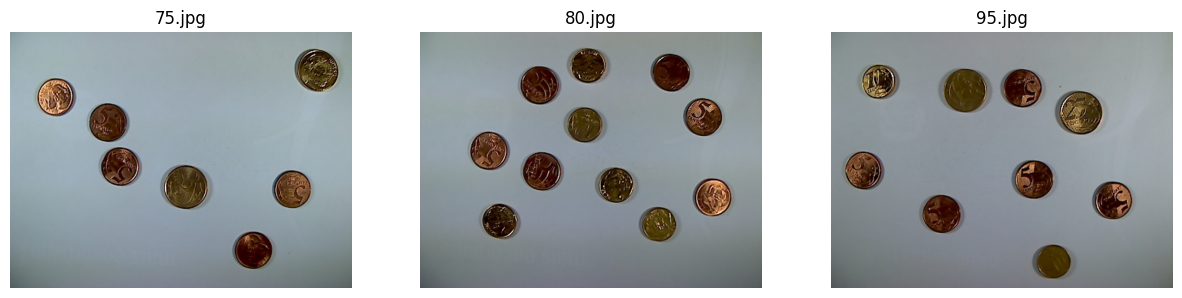

In [4]:
fig, axs = plt.subplots(1,3,figsize=(15, 6))

for i, file in enumerate(filenames):
  plt.subplot(1,3,1+i)
  plt.axis('off')
  plt.title(file)
  img = mpimg.imread(file)
  plt.imshow(img)

In [5]:
import cv2

def seg_and_postprocessing(img, k_cl, k_op):
    binr = cv2.threshold(255 - img, 0, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)[1]

    kernel_cl = np.ones((k_cl, k_cl), np.uint8) 
    kernel_op = np.ones((k_op, k_op), np.uint8) 
    
    close = cv2.morphologyEx(binr, cv2.MORPH_CLOSE, kernel_cl, iterations=1) 
    open = cv2.morphologyEx(close, cv2.MORPH_OPEN, kernel_op, iterations=1)

    plt.figure(figsize=(12,6))
    plt.subplot(1,3,1)
    plt.imshow(binr, cmap='gray')
    plt.axis('off')
    plt.subplot(1,3,2)
    plt.imshow(close, cmap='gray')
    plt.axis('off')
    plt.subplot(1,3,3)
    plt.imshow(open, cmap='gray')
    plt.axis('off')
    plt.show()

    return open

In [6]:
def calc_npixels_label(img, n_labels):
    list_npixels = []
    for v in range(n_labels-1):
        npixels = (img[img == v+1]//(v+1)).sum()
        list_npixels.append(npixels)
    return list_npixels

## Pipeline

1. O primeiro passo é simplificar a imagem, convertendo os 3 canais (R, G, B) para escala de cinza. A equação usada em "img_gray = np.uint8(0.3*img[:,:,0]+0.59*img[:,:,1]+0.11*img[:,:,2])" faz essa conversão de acordo com a luminância, que aproxima a percepção humana de brilho.

2. Ao chamar a função "seg_and_postprocessing", aplicamos a limiarização. O objetivo é separar as modelas do fundo da imagem. Como o fundo é mais claro que as moedas, invertemos a imagem (255 - img) para que as moedas fiquem claras sobre um fundo escuro. O método de Otsu (cv2.THRESH_OTSU) calcula automaticamente o valor de limiar ideal (threshold) que minimiza a variância intra-classe (entre os pixels do fundo e os pixels do objeto), resultando em uma imagem binária (binr) onde as moedas são representadas por pixels brancos (valor 255) e o fundo por pixels pretos (valor 0).

3. Na sequência, ainda na função "seg_and_postprocessing" duas operações morfológicas são aplicadas, sendo elas por fechamento e por abertura. O fechamento é útil para preencher pequenos buracos dentro dos objetos e conectar partes que estão próximas. Por outro lado, a abertura é excelente para remover pequenos ruídos de fundo sem afetar significativamente o tamanho dos objetos maiores.

4. Com a imagem binária processada (seg_img), podemos identificar e rotular cada objeto (moeda) individualmente. Usamos a função cv2.connectedComponentsWithStats, que realiza duas atividades. Primeiro, ela rotula cada componente conectado (região de pixels brancos) com um número único. Feito isso, ela pode retornar estatísticas sobre cada componente, como sua área (número de pixels), o retângulo delimitador (x, y, largura, altura), entre outros.

5. Agora que temos cada moeda identificada, precisamos classificá-la por seu valor. Primeiro, a função "calc_npixels_label" calcula a área de cada objeto rotulado. Ela itera por cada rótulo (ignorando o fundo, que é o rótulo 0) e soma os pixels que pertencem a esse rótulo. A partir das áreas calculadas e analisando as imagens, podemos definir limiares para classificar as moedas. De acordo com o código, menor que 3500 pixels são moedas de 10 centavos, maior que 4600 pixels são de 25 centavos, e nesse limiar entre 3500 e 4600 são as de 5 centavos.

6. Por último, calculamos e exibimos o valor das moedas calculadas

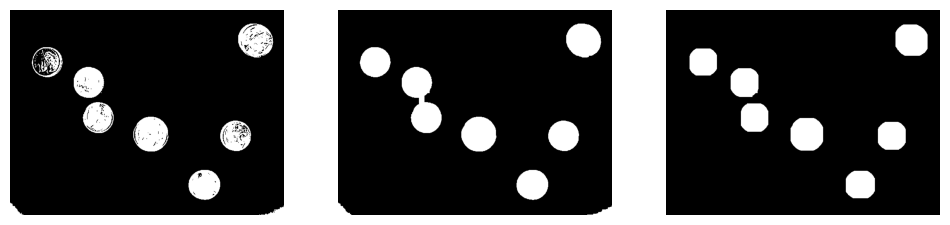

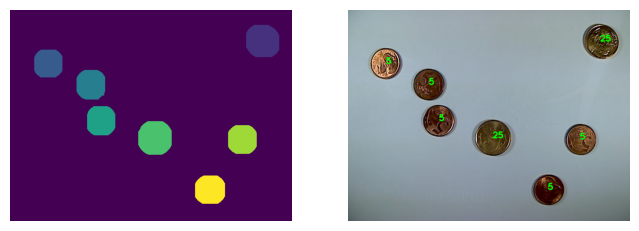

Imagem 75.jpg
Número de moedas 7
[np.int64(4805), np.int64(3638), np.int64(3867), np.int64(3786), np.int64(5016), np.int64(3767), np.int64(3861)]
Valor total: 75



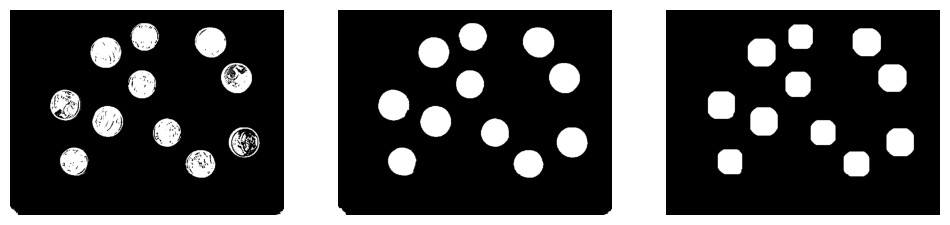

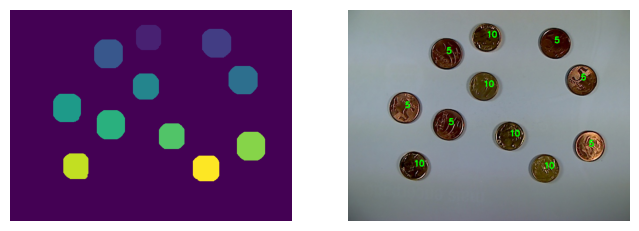

Imagem 80.jpg
Número de moedas 11
[np.int64(2978), np.int64(3793), np.int64(3775), np.int64(3736), np.int64(3132), np.int64(3678), np.int64(3778), np.int64(3064), np.int64(3728), np.int64(3049), np.int64(3183)]
Valor total: 80



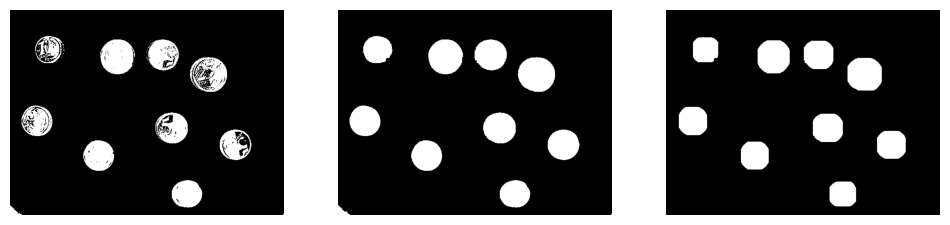

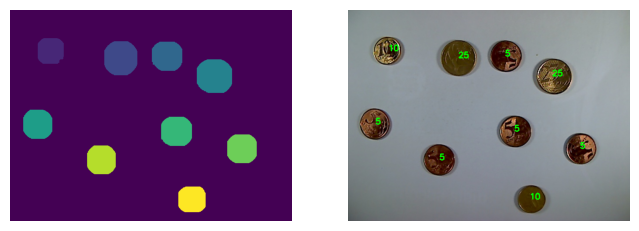

Imagem 95.jpg
Número de moedas 9
[np.int64(3114), np.int64(4997), np.int64(4017), np.int64(5335), np.int64(3845), np.int64(4113), np.int64(3897), np.int64(3766), np.int64(3285)]
Valor total: 95



In [7]:
for i, file in enumerate(filenames):
  img = mpimg.imread(file).astype('uint8')
  img_gray = np.uint8(0.3*img[:,:,0]+0.59*img[:,:,1]+0.11*img[:,:,2])

  seg_img = seg_and_postprocessing(img_gray, 15, 31)
  output = cv2.connectedComponentsWithStats(seg_img, 4)

  plt.figure(figsize=(8,4))
  plt.subplot(1,2,1)
  plt.imshow(output[1])
  plt.axis('off')

  list_npixels = calc_npixels_label(output[1], output[0])

  soma = 0
  for n, p in enumerate(list_npixels):
    x = int(output[3][n+1][0])
    y = int(output[3][n+1][1])

    if p < 3500:
      soma += 10
      cv2.putText(img, '10', (x, y), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
    elif p > 4600:
      soma += 25
      cv2.putText(img, '25', (x, y), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
    else:
      soma += 5
      cv2.putText(img, '5', (x, y), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

  plt.subplot(1,2,2)
  plt.imshow(img)
  plt.axis('off')
  plt.show()

  print('Imagem', file)
  print('Número de moedas', len(list_npixels))
  print(list_npixels)
  print('Valor total:', soma)
  print()

## Referências Úteis

- [Documentação OpenCV](https://docs.opencv.org/4.x/)
- [Livro Digital Image Processing (Gonzalez & Woods)](https://www.cl72.org/090imagePLib/books/Gonzales,Woods-Digital.Image.Processing.4th.Edition.pdf)
- [Documentação scikit-image](https://scikit-image.org/docs/stable/) 
- [Processamento Morfológico de Imagens](https://homepages.inf.ed.ac.uk/rbf/HIPR2/morops.htm)